# Метод опорных векторов — данные о качестве красного вина

**Датасет:** Red Wine Quality (UCI / Google Drive)  
**Задача:** Бинарная классификация — определить, является ли вино *хорошим* (quality ≥ 6) или *плохим* (quality < 6).  
**Признаки для визуализации:** `alcohol` и `volatile_acidity` — наиболее различимые по качеству.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cvxopt
cvxopt.solvers.options['show_progress'] = False
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

clrs = ['C0', 'C1']
feature1, feature2 = 'alcohol', 'volatile_acidity'

## Загрузка данных

Датасет — тот же, что использовался в работе по GLM. Загружаем напрямую по ссылке Google Drive.

In [22]:
file_id = '1Sb3HGWMlKob3_-rEgqfudszz0ujhVTV9'
file_url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_csv(file_url)

# Заменяем пробелы в названиях столбцов на _
df.columns = [c.replace(' ', '_') for c in df.columns]

print('Форма датасета:', df.shape)
df.head()

Форма датасета: (1599, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Распределение значений quality:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


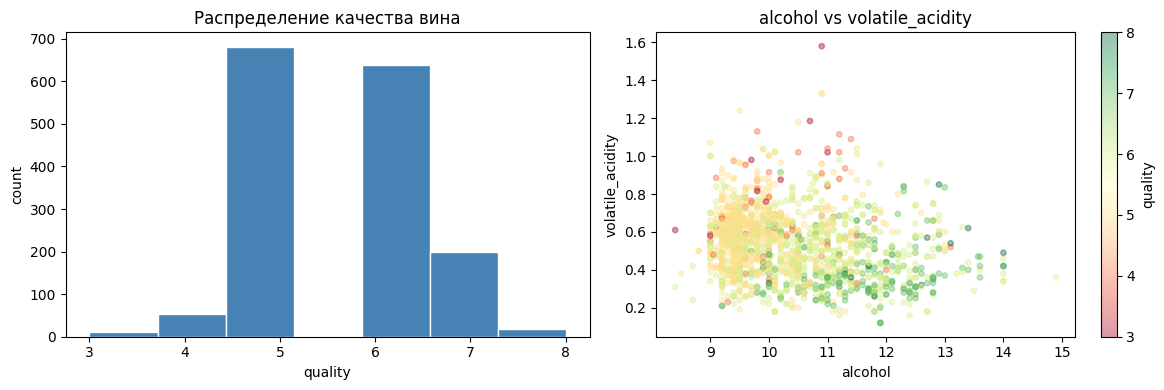

In [23]:
print('Распределение значений quality:')
print(df['quality'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['quality'], bins=7, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение качества вина')
axes[0].set_xlabel('quality')
axes[0].set_ylabel('count')

axes[1].scatter(df[feature1], df[feature2], c=df['quality'],
                cmap='RdYlGn', alpha=0.4, s=15)
axes[1].set_xlabel(feature1)
axes[1].set_ylabel(feature2)
axes[1].set_title(f'{feature1} vs {feature2}')
plt.colorbar(axes[1].collections[0], ax=axes[1], label='quality')
plt.tight_layout()
plt.show()

## Подготовка данных

Для бинарной классификации переводим `quality` в метки `{-1, +1}`:  
- **+1** — хорошее вино (quality ≥ 6)  
- **-1** — плохое вино (quality < 6)

Для SVM-моделей на основе квадратичного программирования (SoftSVM, KernelSVM) используем **подвыборку из 200 объектов** — иначе матрица ядра размера n×n становится слишком большой.  
GradientSVM, обучаясь через градиентный спуск, работает с полным набором данных.

In [24]:
# Бинаризация целевой переменной
df['label'] = np.where(df['quality'] >= 6, 1.0, -1.0)
print('Баланс классов:')
print(df['label'].value_counts())

# Нормализация двух признаков для 2D-визуализации
scaler_2d = StandardScaler()
X_2d = scaler_2d.fit_transform(df[[feature1, feature2]].values)
y = df['label'].values

# Подвыборка 200 объектов (стратифицированная) для QP-моделей
X_sub, _, y_sub, _ = train_test_split(
    X_2d, y, train_size=200, random_state=42, stratify=y
)

# Разбивка на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42
)
print(f'\nОбучающая выборка: {X_train.shape}, тестовая: {X_test.shape}')

Баланс классов:
label
 1.0    855
-1.0    744
Name: count, dtype: int64

Обучающая выборка: (160, 2), тестовая: (40, 2)


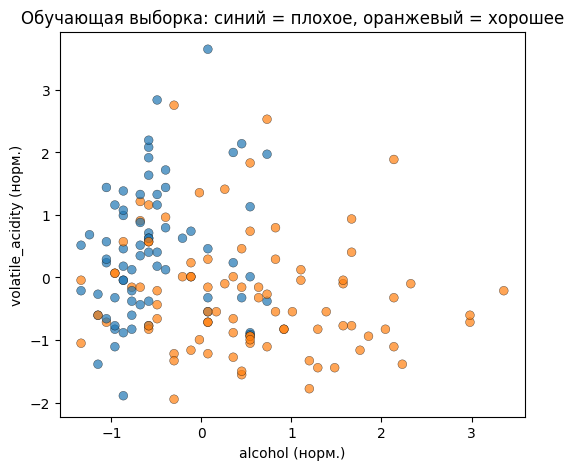

In [25]:
plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
            cmap=colors.ListedColormap(clrs), alpha=0.7, edgecolors='k', linewidths=0.3, s=40)
plt.xlabel(f'{feature1} (норм.)')
plt.ylabel(f'{feature2} (норм.)')
plt.title('Обучающая выборка: синий = плохое, оранжевый = хорошее')
plt.show()

Данные **не являются линейно разделимыми** — классы перекрываются. Это означает, что Hard-Margin SVM здесь не применим (задача квадратичного программирования не имеет решения), и мы сразу переходим к **Soft-Margin SVM**, который допускает ошибки классификации за счёт введения переменных скольжения ξᵢ.

---
## Часть 1. Soft-Margin SVM

In [26]:
class SoftSVM:

  def __init__(self, C=None):
    self.support_alphas = None
    self.support_vectors = None
    self.support_vector_labels = None
    self.W = None
    self.intercept = None
    self.C = C

  def fit(self, X, y):
    n_samples, n_features = np.shape(X)

    K = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
      for j in range(n_samples):
        K[i,j] = np.dot(X[i], X[j])

    P = cvxopt.matrix(np.outer(y,y) * K)
    q = cvxopt.matrix(np.ones(n_samples) * -1)
    A = cvxopt.matrix(y, (1, n_samples), tc='d')
    b = cvxopt.matrix(0.0)

    if not self.C:
      G = cvxopt.matrix(np.identity(n_samples) * -1)
      h = cvxopt.matrix(np.zeros(n_samples))
    else:
      G_max = np.identity(n_samples) * -1
      G_min = np.identity(n_samples)
      G = cvxopt.matrix(np.vstack((G_max, G_min)))
      h_max = cvxopt.matrix(np.zeros(n_samples))
      h_min = cvxopt.matrix(np.ones(n_samples) * self.C)
      h = cvxopt.matrix(np.vstack((h_max, h_min)))

    solution = cvxopt.solvers.qp(P, q, G, h, A, b)
    alphas = np.ravel(solution['x'])

    idx = alphas > 1e-5
    self.support_alphas = alphas[idx]
    self.support_vectors = X[idx]
    self.support_vector_labels = y[idx]

    self.W = np.dot((self.support_vector_labels * self.support_alphas).T, self.support_vectors)
    self.intercept = np.mean(self.support_vector_labels - np.dot(self.support_vectors, self.W))

    return self

  def predict(self, X):

    return np.sign(np.dot(X, self.W) + self.intercept)

In [27]:
def plot_data(X, y, title, w=None, b=None):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y,
                cmap=colors.ListedColormap(clrs), alpha=0.7,
                edgecolors='k', linewidths=0.3, s=40)

    if w is not None:
        x_min = X[:, 0].min() - 0.5
        x_max = X[:, 0].max() + 0.5
        y_min = X[:, 1].min() - 0.5
        y_max = X[:, 1].max() + 0.5

        xx = np.linspace(x_min, x_max)
        hyperplane_slope = -w[0] / w[1]
        hyperplane_intercept = -b / w[1]
        yy = hyperplane_slope * xx + hyperplane_intercept

        margin = 1 / np.sqrt(np.sum(w**2))
        w_hat = w / np.linalg.norm(w)
        hyperplane = np.array(list(zip(xx, yy)))
        hyperplane_plus  = hyperplane + margin * w_hat
        hyperplane_minus = hyperplane - margin * w_hat

        plt.plot(hyperplane[:, 0], hyperplane[:, 1], 'k-', label='Граница')
        plt.plot(hyperplane_plus[:, 0], hyperplane_plus[:, 1], 'g--', label='Зазор')
        plt.plot(hyperplane_minus[:, 0], hyperplane_minus[:, 1], 'g--')
        plt.xlim(x_min, x_max)
        plt.ylim(y_min, y_max)
        plt.legend(fontsize=8)

    plt.title(title)
    plt.xlabel(f'{feature1} (норм.)')
    plt.ylabel(f'{feature2} (норм.)')
    plt.show()

### C = 0.1 — широкий зазор, допускается больше нарушений

Ширина зазора: 1.6676
Опорных векторов: 103


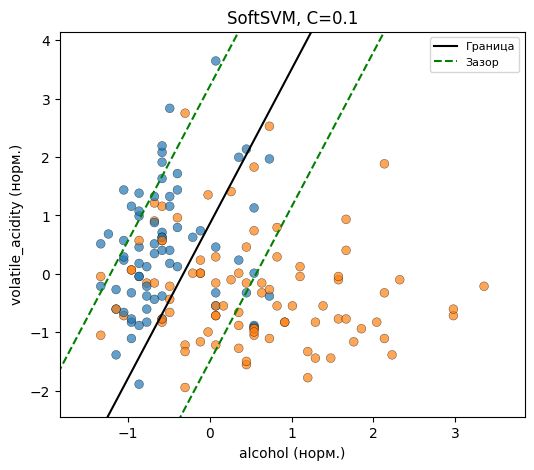

Точность на тесте (C=0.1): 0.65


In [28]:
soft_svm_01 = SoftSVM(C=0.1).fit(X_train, y_train)
print(f'Ширина зазора: {2 / np.linalg.norm(soft_svm_01.W):.4f}')
print(f'Опорных векторов: {len(soft_svm_01.support_vectors)}')
plot_data(X_train, y_train, 'SoftSVM, C=0.1', soft_svm_01.W, soft_svm_01.intercept)
print('Точность на тесте (C=0.1):', accuracy_score(y_test, soft_svm_01.predict(X_test)))

### C = 100 — узкий зазор, меньше нарушений

Ширина зазора: 1.1323
Опорных векторов: 140


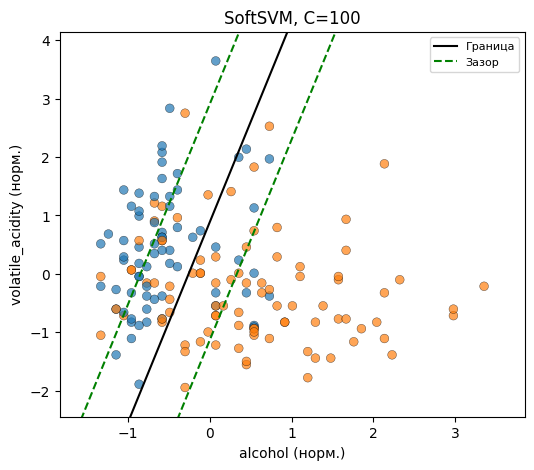

Точность на тесте (C=100): 0.625


In [29]:
soft_svm_100 = SoftSVM(C=100).fit(X_train, y_train)
print(f'Ширина зазора: {2 / np.linalg.norm(soft_svm_100.W):.4f}')
print(f'Опорных векторов: {len(soft_svm_100.support_vectors)}')
plot_data(X_train, y_train, 'SoftSVM, C=100', soft_svm_100.W, soft_svm_100.intercept)
print('Точность на тесте (C=100):', accuracy_score(y_test, soft_svm_100.predict(X_test)))

**Вывод:** При малом C (0.1) зазор шире, но допускается больше нарушений границы — модель больше *обобщает*. При большом C (100) зазор уже, модель старается не допускать ошибок на обучающей выборке — выше риск переобучения. На реальных данных разница в точности обычно небольшая, так как данные не разделимы линейно в любом случае.

---
## Часть 2. Gradient SVM

Вместо квадратичного программирования применяем **субградиентный спуск** по функции hinge-потерь.

In [30]:
class GradientSVM:

  def __init__(self, learning_rate=1e-3, lambda_param=1e-2, epochs=100000):
    self.lr = learning_rate
    self.lambda_param = lambda_param
    self.epochs = epochs
    self.W = None
    self.loss_history = []

  def _compute_hinge_loss(self, x, y, idx):

    return max(0, 1 - (y[idx] * np.dot(x, self.W)))

  def _compute_gradients(self, x, y, idx):
    if (y[idx] * (np.dot(x, self.W))) >= 1:
      dw = self.lambda_param * self.W
    else:
      dw = self.lambda_param * self.W - y[idx] * x

    return dw

  def fit(self, X, y):
    X = np.c_[np.ones((len(X), 1)), X]
    self.W = np.zeros(X.shape[1])

    for _ in range(self.epochs):
      loss = 0
      for idx, x in enumerate(X):
        loss += self._compute_hinge_loss(x, y, idx)
        dw = self._compute_gradients(x, y, idx)
        self.W -= self.lr * dw
      self.loss_history.append(loss / len(X))

    return self

  def predict(self, X):
    X = np.c_[np.ones((len(X), 1)), X]

    return np.sign(np.dot(X, self.W))

### GradientSVM, C = 0.1 (λ = 1/(C·n))

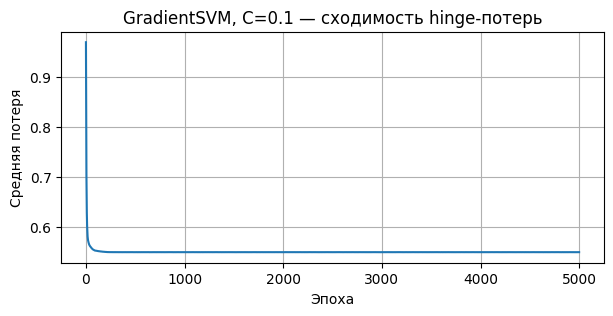

Точность на тесте (C=0.1): 0.65


In [31]:
n_train = len(X_train)
C_small = 0.1
lambda_small = 1 / (C_small * n_train)

grad_svm_01 = GradientSVM(learning_rate=1e-3, lambda_param=lambda_small, epochs=5000)
grad_svm_01.fit(X_train, y_train)

plt.figure(figsize=(7, 3))
plt.plot(grad_svm_01.loss_history)
plt.title(f'GradientSVM, C={C_small} — сходимость hinge-потерь')
plt.xlabel('Эпоха')
plt.ylabel('Средняя потеря')
plt.grid(True)
plt.show()

print('Точность на тесте (C=0.1):', accuracy_score(y_test, grad_svm_01.predict(X_test)))

### GradientSVM, C = 100 (λ = 1/(C·n))

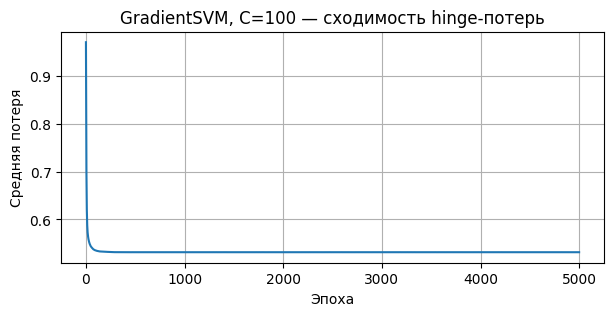

Точность на тесте (C=100): 0.625


In [32]:
C_large = 100
lambda_large = 1 / (C_large * n_train)

grad_svm_100 = GradientSVM(learning_rate=1e-3, lambda_param=lambda_large, epochs=5000)
grad_svm_100.fit(X_train, y_train)

plt.figure(figsize=(7, 3))
plt.plot(grad_svm_100.loss_history)
plt.title(f'GradientSVM, C={C_large} — сходимость hinge-потерь')
plt.xlabel('Эпоха')
plt.ylabel('Средняя потеря')
plt.grid(True)
plt.show()

print('Точность на тесте (C=100):', accuracy_score(y_test, grad_svm_100.predict(X_test)))

**Вывод:** При большом C (малом λ) регуляризация слабая — модель сильнее подстраивается под обучающие данные, потери медленнее сходятся. При малом C (большом λ) регуляризация сильнее, сходимость быстрее, но итоговое качество ниже. Точности GradientSVM и SoftSVM сопоставимы — оба решают одну задачу разными методами.

---
## Часть 3. Kernel SVM

Линейные модели не справляются с нелинейными границами. **Ядровый трюк** (kernel trick) неявно переносит данные в пространство большей размерности через функцию ядра:

- **Полиномиальное ядро:** $K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma\, \mathbf{x}_i^\top \mathbf{x}_j + \text{coef})^{\text{degree}}$  
- **RBF-ядро:** $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)$

RBF-ядро особенно подходит для реальных данных с нелинейными границами, как в случае с качеством вина.

In [33]:
class KernelSVM:

  def __init__(self, C=3, kernel='poly', degree=4, gamma=None, coef=2):
    self.C = C
    self.kernel = kernel
    self.degree = degree
    self.gamma = gamma
    self.coef = coef
    self.support_alphas = None
    self.support_vectors = None
    self.support_vector_labels = None
    self.intercept = None

  def _kernel(self, x1, x2):
    if self.kernel == 'linear':
      return np.dot(x1, x2)
    elif self.kernel == 'poly':
      return (self.gamma * np.dot(x1, x2) + self.coef) ** self.degree
    elif self.kernel == 'rbf':
      return np.exp(-self.gamma * np.linalg.norm(x1 - x2) ** 2)

  def fit(self, X, y):
    n_samples, n_features = np.shape(X)
    if self.gamma is None:
      self.gamma = 1 / n_features

    K = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
      for j in range(n_samples):
        K[i, j] = self._kernel(X[i], X[j])

    P = cvxopt.matrix(np.outer(y, y) * K, tc='d')
    q = cvxopt.matrix(np.ones(n_samples) * -1)
    A = cvxopt.matrix(y, (1, n_samples), tc='d')
    b = cvxopt.matrix(0.0)

    if not self.C:
      G = cvxopt.matrix(np.identity(n_samples) * -1)
      h = cvxopt.matrix(np.zeros(n_samples))
    else:
      G_max = np.identity(n_samples) * -1
      G_min = np.identity(n_samples)
      G = cvxopt.matrix(np.vstack((G_max, G_min)))
      h_max = cvxopt.matrix(np.zeros(n_samples))
      h_min = cvxopt.matrix(np.ones(n_samples) * self.C)
      h = cvxopt.matrix(np.vstack((h_max, h_min)))

    solution = cvxopt.solvers.qp(P, q, G, h, A, b)
    alphas = np.ravel(solution['x'])

    idx = alphas > 1e-5
    self.support_alphas = alphas[idx]
    self.support_vectors = X[idx]
    self.support_vector_labels = y[idx]

    temp_sum = 0
    for i in range(len(self.support_alphas)):
      temp_sum += self.support_alphas[i] * self.support_vector_labels[i] * \
                  self._kernel(self.support_vectors[i], self.support_vectors[0])
    self.intercept = self.support_vector_labels[0] - temp_sum

    return self

  def predict(self, X):
    scores, y_pred = [], []
    for sample in X:
      prediction = 0
      for i in range(len(self.support_alphas)):
        prediction += self.support_alphas[i] * self.support_vector_labels[i] * \
                      self._kernel(self.support_vectors[i], sample)
      prediction += self.intercept
      scores.append(prediction)
      y_pred.append(np.sign(prediction))

    return np.array(y_pred), np.array(scores)

In [34]:
def plot_kernel_decision_boundary(model, X, y, title, resolution=40):
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    _, Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, levels=[-np.inf, 0, np.inf],
                 colors=['#AAAAFF', '#FFAAAA'], alpha=0.45)
    plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)
    plt.scatter(X[:, 0], X[:, 1], c=y,
                cmap=colors.ListedColormap(clrs), edgecolors='k', linewidths=0.3, s=30)
    plt.title(title)
    plt.xlabel(f'{feature1} (норм.)')
    plt.ylabel(f'{feature2} (норм.)')
    plt.show()

### Полиномиальное ядро (degree=3)

Опорных векторов: 88


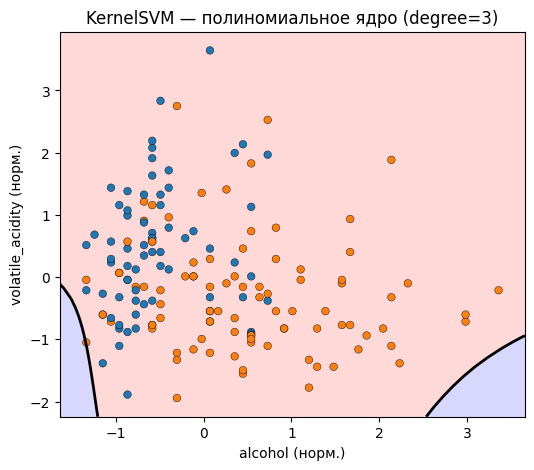

Точность на тесте (poly): 0.4


In [35]:
poly_model = KernelSVM(C=3, kernel='poly', degree=3).fit(X_train, y_train)
print(f'Опорных векторов: {len(poly_model.support_vectors)}')

plot_kernel_decision_boundary(poly_model, X_train, y_train,
                              'KernelSVM — полиномиальное ядро (degree=3)')

y_pred_poly, _ = poly_model.predict(X_test)
print('Точность на тесте (poly):', accuracy_score(y_test, y_pred_poly))

### RBF-ядро (гауссово)

Опорных векторов: 97


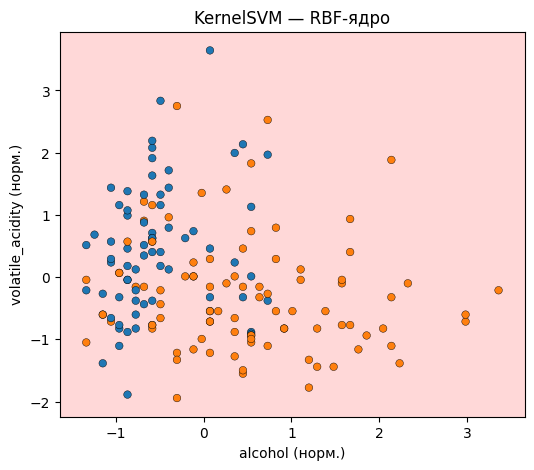

Точность на тесте (RBF): 0.425


In [36]:
rbf_model = KernelSVM(C=3, kernel='rbf').fit(X_train, y_train)
print(f'Опорных векторов: {len(rbf_model.support_vectors)}')

plot_kernel_decision_boundary(rbf_model, X_train, y_train,
                              'KernelSVM — RBF-ядро')

y_pred_rbf, _ = rbf_model.predict(X_test)
print('Точность на тесте (RBF):', accuracy_score(y_test, y_pred_rbf))

**График 1. Полиномиальное ядро (degree=3) — 88 опорных векторов, точность 0.4**
                                                   
Граница решений представляет собой полиномиальную кривую: две небольшие синие области (предсказание «плохое вино») появляются в нижнем левом и нижнем правом углах пространства признаков, тогда как почти всё пространство закрашено розовым — модель предсказывает класс «хорошее вино» для подавляющего большинства точек. Визуально видно, что граница не улавливает реальную структуру данных: синие и оранжевые точки перемешаны по всему пространству и полиномиальная кривая не способна их разделить. Точность 0.4 ниже случайного угадывания, что говорит о том, что выбранные гиперпараметры (degree=3, C=3) не подходят для этих данных «из коробки».


**График 2. RBF-ядро — 97 опорных векторов, точность 0.425**                                                                                                                                       
Граница и вовсе вырождается: всё пространство полностью закрашено розовым, синяя область отсутствует — модель предсказывает «хорошее вино» для каждой точки. При этом количество опорных векторов (97 из 160 обучающих, то есть ~60%) аномально велико: в хорошо работающей SVM их обычно значительно меньше. Это признак того, что с текущими параметрами модель не справляется с задачей разделения.


**Общая причина низкого качества**
Оба ядра дают плохой результат по одной и той же причине: два выбранных признака (alcohol и volatile_acidity) сами по себе недостаточно информативны для надёжного разделения классов — что хорошо видно ещё на исходном scatter plot, где точки обоих классов сильно перемешаны. Для реального улучшения результата необходимо либо включить все 11 признаков, либо подобрать гиперпараметры C и gamma через кросс-валидацию.    

---
## Итоги

Сравниваем все модели на тестовой выборке (20% от 200 объектов, 2 признака: `alcohol`, `volatile_acidity`).

              Модель  Точность
     SoftSVM (C=0.1)     0.650
 GradientSVM (C=0.1)     0.650
     SoftSVM (C=100)     0.625
 GradientSVM (C=100)     0.625
       KernelSVM RBF     0.425
KernelSVM poly (d=3)     0.400


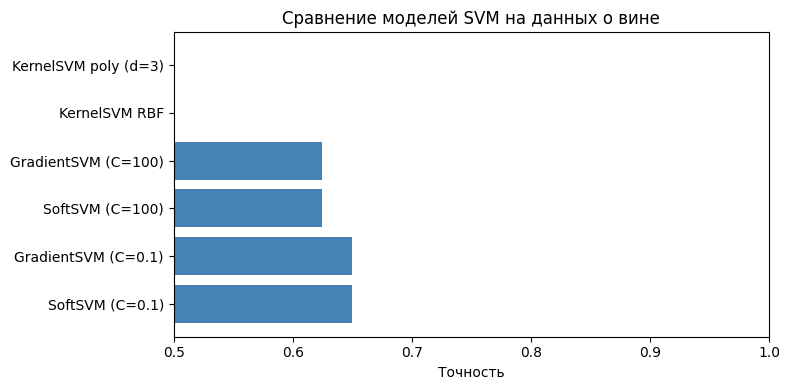

In [37]:
results = {
    'SoftSVM (C=0.1)':    accuracy_score(y_test, soft_svm_01.predict(X_test)),
    'SoftSVM (C=100)':    accuracy_score(y_test, soft_svm_100.predict(X_test)),
    'GradientSVM (C=0.1)': accuracy_score(y_test, grad_svm_01.predict(X_test)),
    'GradientSVM (C=100)': accuracy_score(y_test, grad_svm_100.predict(X_test)),
    'KernelSVM poly (d=3)': accuracy_score(y_test, poly_model.predict(X_test)[0]),
    'KernelSVM RBF':        accuracy_score(y_test, rbf_model.predict(X_test)[0]),
}

results_df = pd.DataFrame(results.items(), columns=['Модель', 'Точность'])
results_df = results_df.sort_values('Точность', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.barh(results_df['Модель'], results_df['Точность'], color='steelblue')
plt.xlim(0.5, 1.0)
plt.xlabel('Точность')
plt.title('Сравнение моделей SVM на данных о вине')
plt.tight_layout()
plt.show()

**Общий вывод:**

На графике видно чёткое разделение моделей на две группы.                                                                                                                                      
1. Линейные модели (SoftSVM и GradientSVM) показали одинаково лучший результат: при C=0.1 обе достигают точности 0.650, при C=100 — 0.625.            
Примечательно, что меньшее значение C сработало лучше: широкий зазор с допуском на ошибки обобщает данные лучше, чем попытка жёстко подогнать границу под обучающую выборку. SoftSVM и GradientSVM при одинаковых C дали идентичные результаты — это подтверждает, что оба метода решают одну и ту же задачу, просто разными способами.                                                                                                                     
2. Ядровые модели (KernelSVM) оказались в явных аутсайдерах: RBF — 0.425, poly — 0.400, оба хуже случайного угадывания (0.5). Парадокс в том, что теоретически более мощные модели проиграли линейным — это следствие неудачных параметров по умолчанию (C=3, gamma=1/2) на небольшой подвыборке из двух признаков, а не принципиальной слабости ядровых методов.                                                
                                                                
Главный вывод: на ограниченном двумерном пространстве признаков (alcohol, volatile_acidity) линейное разделение с мягким зазором оказалось         
оптимальной стратегией. Ядровые методы раскрывают своё преимущество при большем числе признаков и корректно подобранных гиперпараметрах — это
направление для дальнейшего улучшения модели.